In [33]:
import numpy as np
import pandas as pd

In [34]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [35]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2325,ham,Ok lor.,NaN,NaN,NaN
3134,ham,Ok going to sleep. Hope i can meet her.,NaN,NaN,NaN
577,ham,ÌÏ wait 4 me in sch i finish ard 5..,NaN,NaN,NaN
2610,ham,"Awesome, text me when you're restocked",NaN,NaN,NaN
4709,ham,"Haha awesome, I might need to take you up on t...",NaN,NaN,NaN


In [36]:
df.shape

(6000, 5)

In [ ]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          6000 non-null   object
 1   v2          6000 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 234.5+ KB


In [38]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [39]:
df.sample(5)

,v1,v2
303,ham,He is a womdarfull actor
3413,ham,Where do you need to go to get it?
2776,ham,We confirm eating at esplanade?
4454,ham,I'm home. Ard wat time will u reach?
937,ham,K:)k.are you in college?


In [40]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
5762,spam,we ' ll show you how to get in for free ! stop...
4697,ham,"Okey dokey, iÛ÷ll be over in a bit just sorti..."
5839,spam,"re : 63 % - off \ / iagra , cialis , ambien , ..."
1389,ham,Oh k.i think most of wi and nz players unsold.
2508,ham,Yup...


In [41]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [42]:
df['target'] = encoder.fit_transform(df['target'])

In [43]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [44]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [45]:
# check for duplicate values
df.duplicated().sum()

424

In [46]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [47]:
df.duplicated().sum()

0

In [48]:
df.shape

(5576, 2)

## 2.EDA

In [49]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [50]:
df['target'].value_counts()

target
0    4516
1    1060
Name: count, dtype: int64

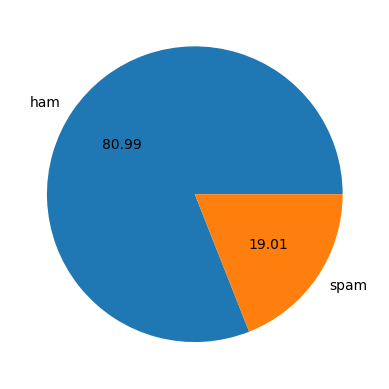

In [51]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [34]:
# Data is imbalanced

In [52]:
import nltk

In [53]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [54]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Celine Ooi Zhi
[nltk_data]     Ni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [55]:
df['num_characters'] = df['text'].apply(len)

In [56]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [57]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [58]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [59]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [60]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [61]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5576.000000,5576.000000,5576.000000
mean,185.242109,38.586263,3.091105
std,741.990071,143.412410,8.338228
min,2.000000,1.000000,1.000000
25%,37.000000,9.000000,1.000000
50%,66.000000,16.000000,2.000000
75%,134.000000,29.000000,3.000000
max,16343.000000,3772.000000,254.000000


In [62]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [63]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1060.000000,1060.000000,1060.000000
mean,674.260377,130.024528,8.505660
std,1609.105768,311.711459,17.933698
min,5.000000,1.000000,1.000000
25%,141.000000,27.000000,2.000000
50%,158.000000,32.000000,4.000000
75%,457.250000,92.250000,7.000000
max,16343.000000,3772.000000,254.000000


In [64]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

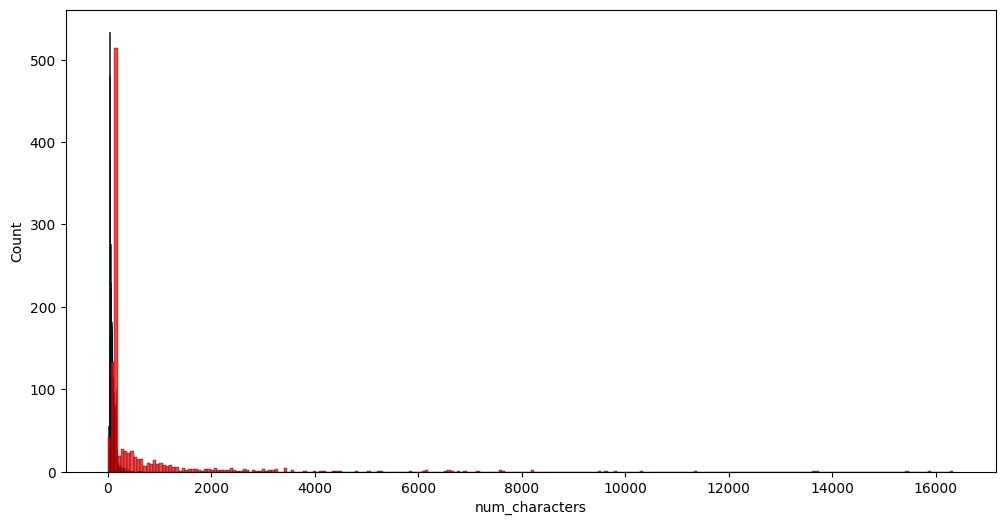

In [65]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

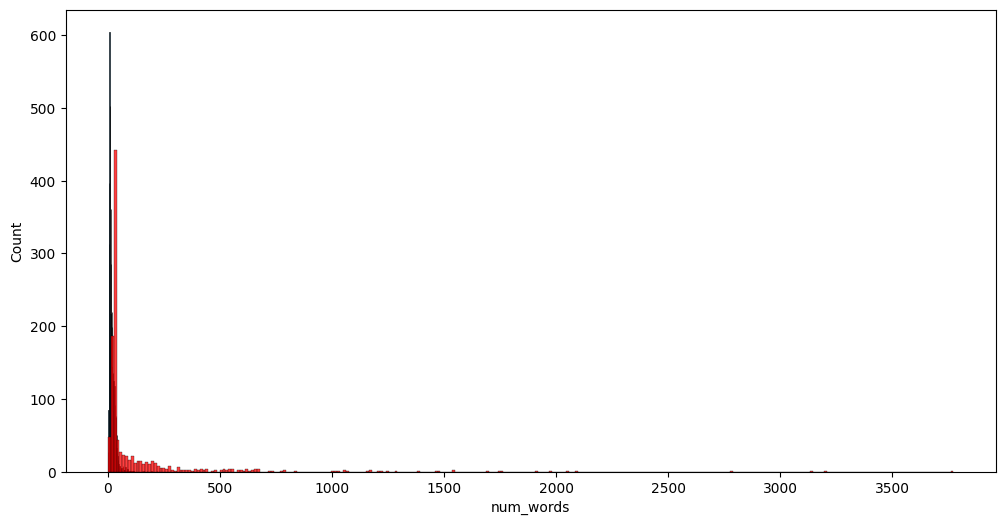

In [66]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

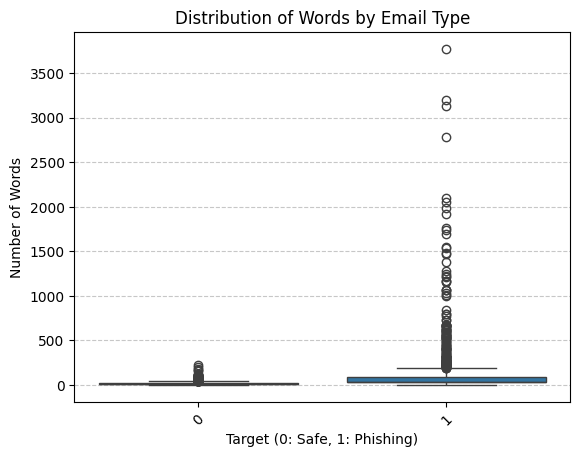

In [70]:
sns.boxplot(x='target', y='num_words', data=df)
plt.xlabel('Target (0: Safe, 1: Phishing)')
plt.ylabel('Number of Words')
plt.title('Distribution of Words by Email Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

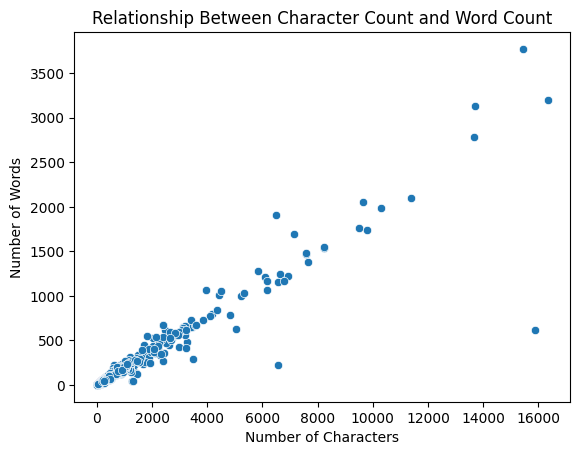

In [68]:
sns.scatterplot(x='num_characters', y='num_words', data=df)
plt.xlabel('Number of Characters')
plt.ylabel('Number of Words')
plt.title('Relationship Between Character Count and Word Count')
plt.show()

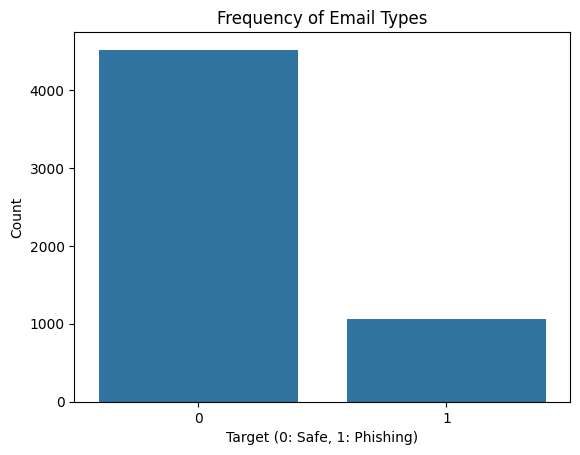

In [71]:
sns.countplot(x='target', data=df)
plt.xlabel('Target (0: Safe, 1: Phishing)')
plt.ylabel('Count')
plt.title('Frequency of Email Types')
plt.show()

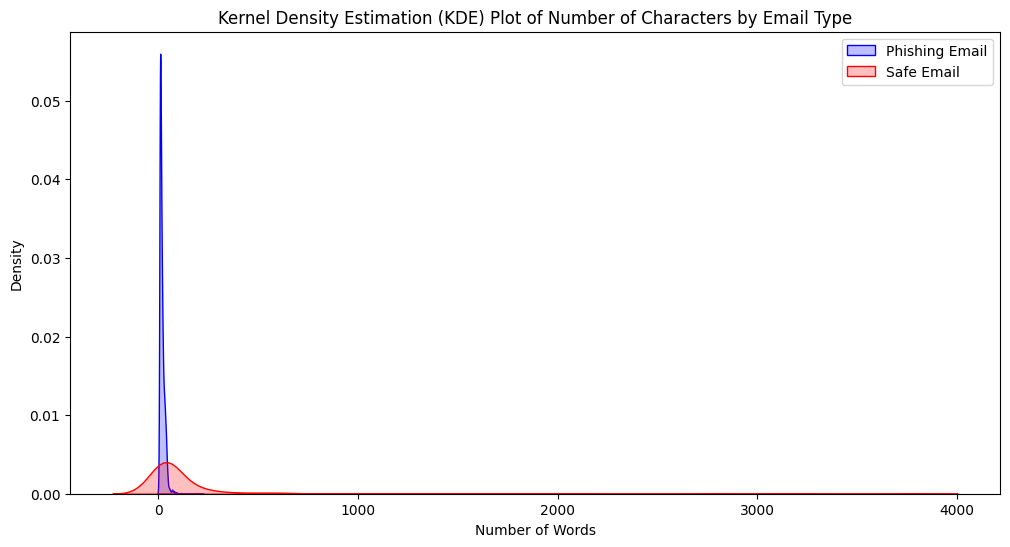

In [72]:
plt.figure(figsize=(12, 6))

# Safe Email KDE plot
sns.kdeplot(df[df['target'] == 0]['num_words'], color='blue', label='Phishing Email', fill=True)

# Phishing Email KDE plot
sns.kdeplot(df[df['target'] == 1]['num_words'], color='red', label='Safe Email', fill=True)

# Add labels and title
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.title('Kernel Density Estimation (KDE) Plot of Number of Characters by Email Type')
plt.legend()

# Show plot
plt.show()

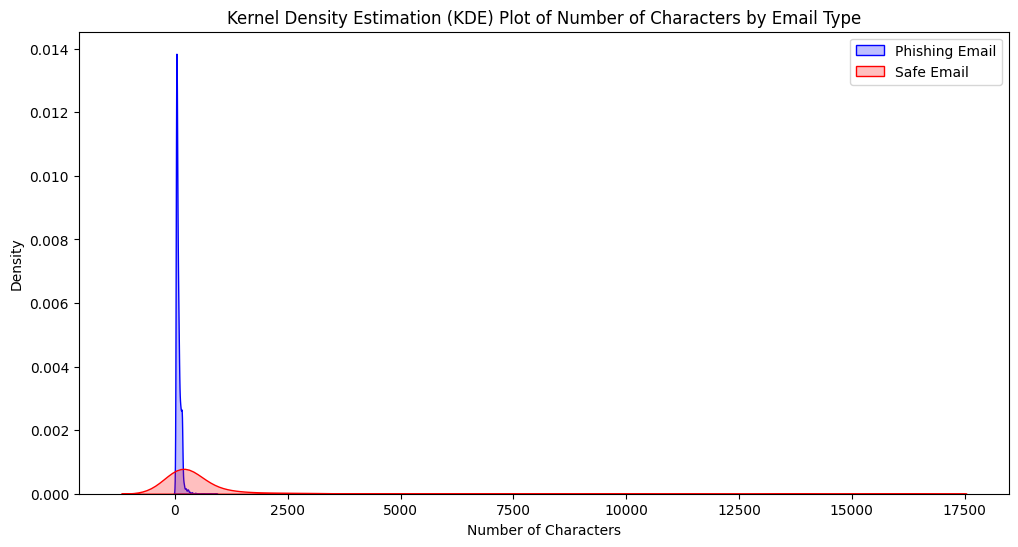

In [73]:
plt.figure(figsize=(12, 6))

# Safe Email KDE plot
sns.kdeplot(df[df['target'] == 0]['num_characters'], color='blue', label='Phishing Email', fill=True)

# Phishing Email KDE plot
sns.kdeplot(df[df['target'] == 1]['num_characters'], color='red', label='Safe Email', fill=True)

# Add labels and title
plt.xlabel('Number of Characters')
plt.ylabel('Density')
plt.title('Kernel Density Estimation (KDE) Plot of Number of Characters by Email Type')
plt.legend()

# Show plot
plt.show()

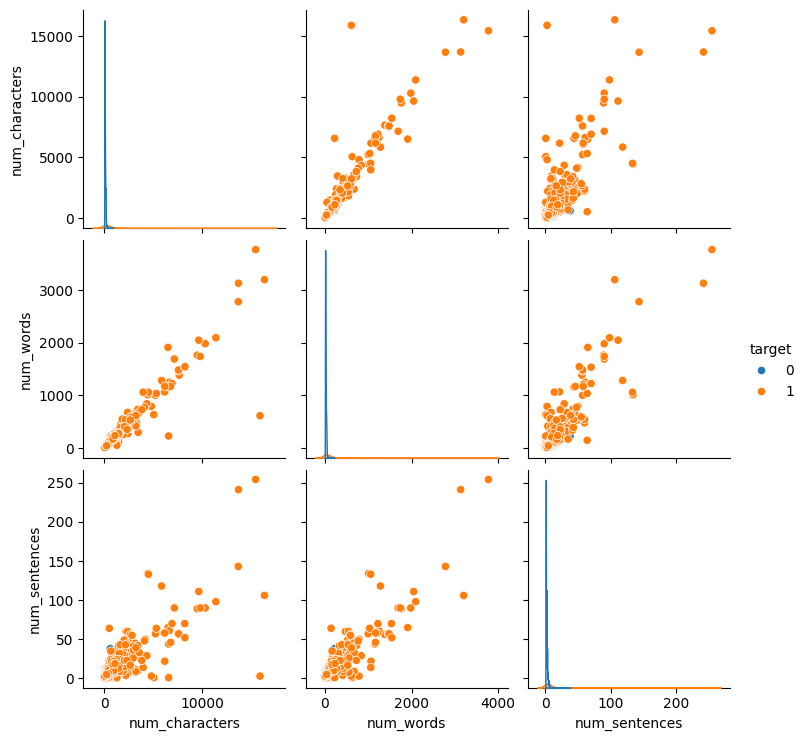

In [74]:
sns.pairplot(df,hue='target')

<Axes: >

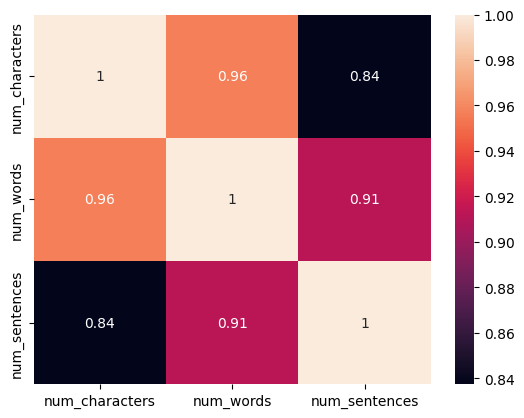

In [75]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [76]:
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer

In [77]:
def transform_text(text):
    ps = PorterStemmer()
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [78]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [79]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [80]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [81]:
df['transformed_text'] = df['text'].apply(transform_text)

In [82]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [83]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [84]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

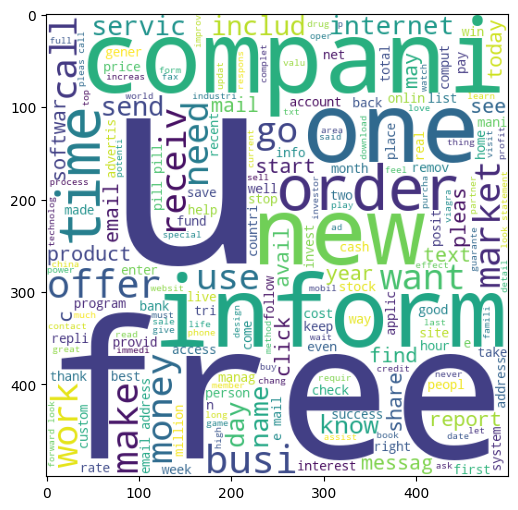

In [85]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [86]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

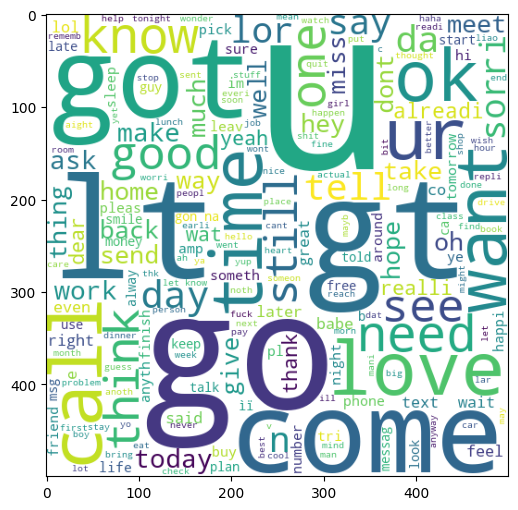

In [87]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [88]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [89]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [90]:
len(spam_corpus)

67399

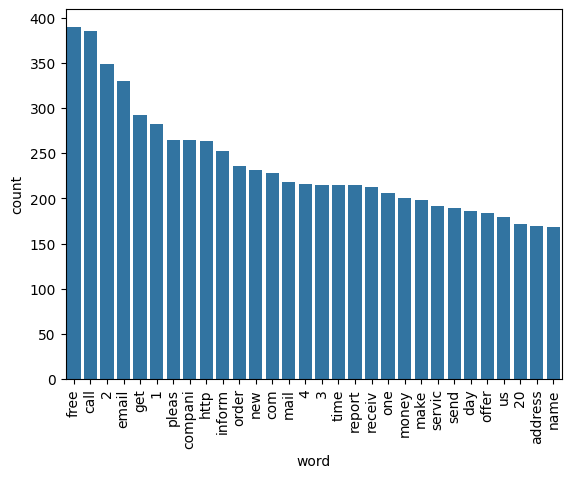

In [91]:
from collections import Counter
# Create a DataFrame from the Counter's most_common results
data = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Use seaborn's barplot function
sns.barplot(x='word', y='count', data=data)  # Pass the DataFrame directly

# Rotate x-axis labels for better readability
plt.xticks(rotation='vertical')

# Display the plot
plt.show()

In [92]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [93]:
len(ham_corpus)

35404

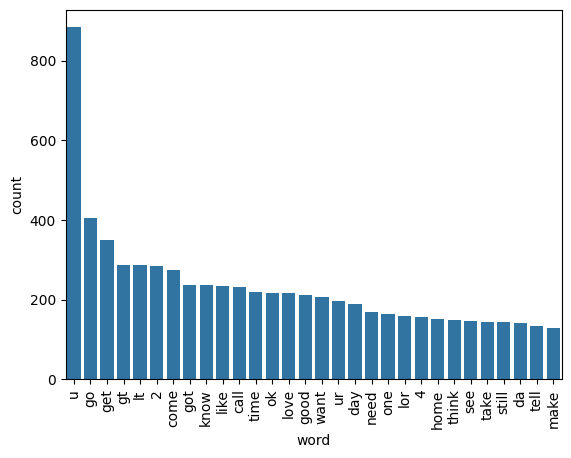

In [94]:
from collections import Counter
# Create a DataFrame from the Counter's most_common results
data = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Use seaborn's barplot function
sns.barplot(x='word', y='count', data=data)  # Pass the DataFrame directly

# Rotate x-axis labels for better readability
plt.xticks(rotation='vertical')

# Display the plot
plt.show()

In [95]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

In [96]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [97]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [470]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [483]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [98]:
X.shape

(5576, 3000)

In [99]:
y = df['target'].values

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [102]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [103]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [104]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9274193548387096
[[844  61]
 [ 20 191]]
0.7579365079365079


In [105]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9623655913978495
[[901   4]
 [ 38 173]]
0.9774011299435028


In [106]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9390681003584229
[[902   3]
 [ 65 146]]
0.9798657718120806


In [493]:
# tfidf --> MNB

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [108]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [109]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [110]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [111]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9650537634408602, 0.9623655913978495)

In [112]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9650537634408602
Precision -  0.9623655913978495
For  KN
Accuracy -  0.8458781362007168
Precision -  1.0
For  NB
Accuracy -  0.9623655913978495
Precision -  0.9774011299435028
For  DT
Accuracy -  0.9148745519713262
Precision -  0.8625
For  LR
Accuracy -  0.9399641577060932
Precision -  0.9556962025316456
For  RF
Accuracy -  0.9632616487455197
Precision -  0.9829545454545454


c:\Users\Celine Ooi Zhi Ni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.9480286738351255
Precision -  0.9473684210526315
For  BgC
Accuracy -  0.9480286738351255
Precision -  0.9047619047619048
For  ETC
Accuracy -  0.9713261648745519
Precision -  0.9786096256684492
For  GBDT
Accuracy -  0.9238351254480287
Precision -  0.9921875
For  xgb
Accuracy -  0.9525089605734767
Precision -  0.9647058823529412


In [113]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [114]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.845878,1.000000
9,GBDT,0.923835,0.992188
5,RF,0.963262,0.982955
8,ETC,0.971326,0.978610
2,NB,0.962366,0.977401
10,xgb,0.952509,0.964706
0,SVC,0.965054,0.962366
4,LR,0.939964,0.955696
6,AdaBoost,0.948029,0.947368
7,BgC,0.948029,0.904762


In [115]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [116]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.845878
1,GBDT,Accuracy,0.923835
2,RF,Accuracy,0.963262
3,ETC,Accuracy,0.971326
4,NB,Accuracy,0.962366
5,xgb,Accuracy,0.952509
6,SVC,Accuracy,0.965054
7,LR,Accuracy,0.939964
8,AdaBoost,Accuracy,0.948029
9,BgC,Accuracy,0.948029


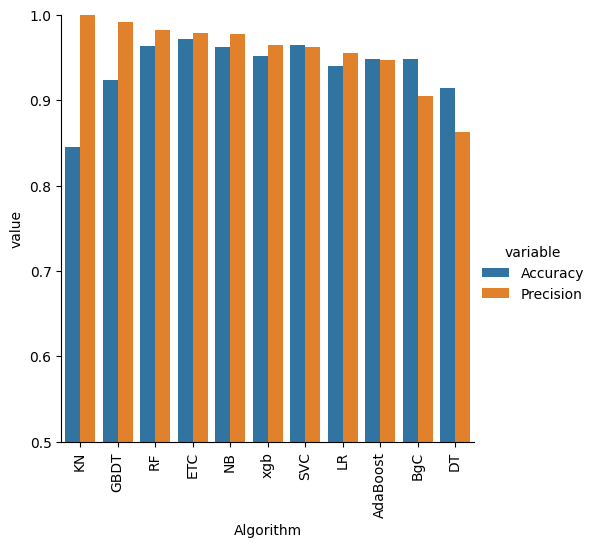

In [117]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [118]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [119]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [120]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [121]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [122]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [123]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.845878,1.000000,0.845878,1.000000,0.845878,1.000000,0.845878,1.000000
1,GBDT,0.923835,0.992188,0.923835,0.992188,0.923835,0.992188,0.923835,0.992188
2,RF,0.963262,0.982955,0.963262,0.982955,0.963262,0.982955,0.963262,0.982955
3,ETC,0.971326,0.978610,0.971326,0.978610,0.971326,0.978610,0.971326,0.978610
4,NB,0.962366,0.977401,0.962366,0.977401,0.962366,0.977401,0.962366,0.977401
5,xgb,0.952509,0.964706,0.952509,0.964706,0.952509,0.964706,0.952509,0.964706
6,SVC,0.965054,0.962366,0.965054,0.962366,0.965054,0.962366,0.965054,0.962366
7,LR,0.939964,0.955696,0.939964,0.955696,0.939964,0.955696,0.939964,0.955696
8,AdaBoost,0.948029,0.947368,0.948029,0.947368,0.948029,0.947368,0.948029,0.947368
9,BgC,0.948029,0.904762,0.948029,0.904762,0.948029,0.904762,0.948029,0.904762


In [124]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [125]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [126]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [127]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9740143369175627
Precision 0.9789473684210527


In [128]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [129]:
from sklearn.ensemble import StackingClassifier

In [130]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [131]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9758064516129032
Precision 0.96


In [132]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(clf,open('model.pkl','wb'))